# Tutorial de Clustering DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) este un algoritm de clustering bazat pe densitate, care grupează punctele de date în funcție de densitatea lor locală. Spre deosebire de K-Means, DBSCAN nu necesită specificarea numărului de clustere și poate detecta clustere de forme arbitrare, precum și puncte de zgomot (outliers).

## 1. Teorie și Definiții

### Ce este DBSCAN?

DBSCAN este un algoritm de clustering care funcționează pe principiul identificării zonelor dense de puncte de date, separate de zone mai puțin dense. Algoritmul identifică trei tipuri de puncte:

- **Puncte de bază**: Puncte care au cel puțin `min_samples` puncte în vecinătatea lor (definită de `eps`).

- **Puncte de frontieră**: Puncte care au mai puțin de `min_samples` în vecinătate, dar sunt în vecinătatea unui punct de bază.

- **Puncte de zgomot**: Puncte care nu sunt nici de bază, nici de frontieră.

### Pașii Algoritmului DBSCAN:

1. **Selectare punct de start**: Alege un punct de date neetichetat.

2. **Verificare densitate**: Dacă punctul are cel puțin `min_samples` în vecinătatea `eps`, formează un nou cluster.

3. **Expandare cluster**: Adaugă toate punctele din vecinătate la cluster și repetă procesul pentru fiecare punct nou adăugat.

4. **Repetare**: Continuă până când toate punctele sunt etichetate sau marcate ca zgomot.

### Concepte Cheie:

- **`eps`**: Raza de vecinătate pentru a determina densitatea.

- **`min_samples`**: Numărul minim de puncte necesare pentru a forma un cluster dens.

- **Zgomot (Noise)**: Puncte care nu aparțin niciunui cluster.

## 2. Implementare de la Zero

Să implementăm DBSCAN de la zero folosind NumPy.

In [1]:
import numpy as np
from collections import deque

class DBSCAN:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples

    def fit(self, X):
        self.labels = np.full(X.shape[0], -1)  # Toate punctele sunt neetichetate initial
        cluster_id = 0

        for i in range(X.shape[0]):
            if self.labels[i] != -1:  # Punctul a fost deja etichetat
                continue

            # Gaseste toti vecinii din raza eps
            neighbors = self._region_query(X, i)

            if len(neighbors) < self.min_samples:  # Punct de zgomot
                self.labels[i] = -1
            else:
                self._expand_cluster(X, i, neighbors, cluster_id)
                cluster_id += 1

    def _region_query(self, X, i):
        distances = np.linalg.norm(X - X[i], axis=1)
        return np.where(distances <= self.eps)[0]

    def _expand_cluster(self, X, i, neighbors, cluster_id):
        self.labels[i] = cluster_id
        queue = deque(neighbors)

        while queue:
            j = queue.popleft()

            if self.labels[j] == -1:  # Punct neetichetat
                self.labels[j] = cluster_id

                # Gaseste vecinii punctului j
                new_neighbors = self._region_query(X, j)

                if len(new_neighbors) >= self.min_samples:
                    queue.extend(new_neighbors)

### Exemplu de Utilizare

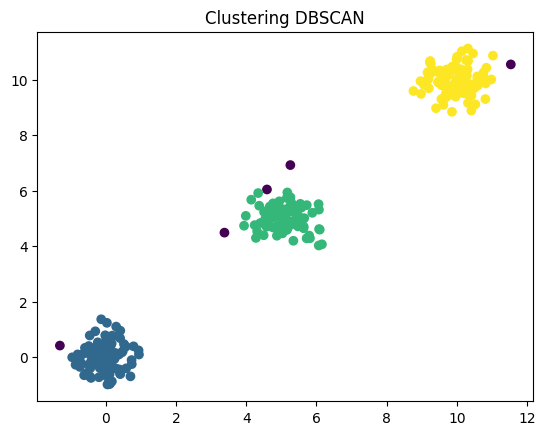

In [4]:
import matplotlib.pyplot as plt

# Generare date de exemplu
np.random.seed(42)
X = np.vstack([
    np.random.normal(loc=[0, 0], scale=0.5, size=(100, 2)),
    np.random.normal(loc=[5, 5], scale=0.5, size=(100, 2)),
    np.random.normal(loc=[10, 10], scale=0.5, size=(100, 2))
])

# Aplicare DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(X)

# Vizualizare clustere
plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels, cmap='viridis')
plt.title('Clustering DBSCAN')
plt.show()

## 3. Exerciții

### Exercițiul 1: Implementare DBSCAN pe un Set de Date Nou

Generează un set de date cu clustere de forme complexe și aplică DBSCAN:

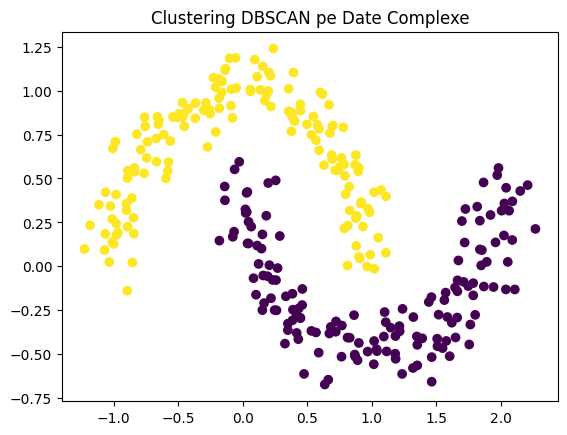

In [5]:
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# Aplicare DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X)

# Vizualizare clustere
plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels, cmap='viridis')
plt.title('Clustering DBSCAN pe Date Complexe')
plt.show()

### Exercițiul 2: Comparație cu Scikit-Learn

Compară implementarea ta cu clasa `DBSCAN` din Scikit-Learn. Folosește următorul cod pentru a rula DBSCAN din Scikit-Learn:

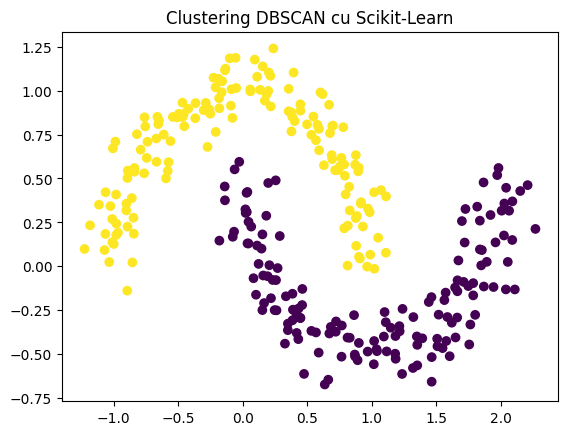

In [6]:
from sklearn.cluster import DBSCAN as SKLearnDBSCAN

sklearn_dbscan = SKLearnDBSCAN(eps=0.2, min_samples=5)
sklearn_labels = sklearn_dbscan.fit_predict(X)

# Vizualizare rezultate
plt.scatter(X[:, 0], X[:, 1], c=sklearn_labels, cmap='viridis')
plt.title('Clustering DBSCAN cu Scikit-Learn')
plt.show()

### Exercițiul 3: Analiza Parametrilor

Experimentează cu diferite valori ale parametrilor `eps` și `min_samples` pentru a vedea cum afectează rezultatele clusteringului.

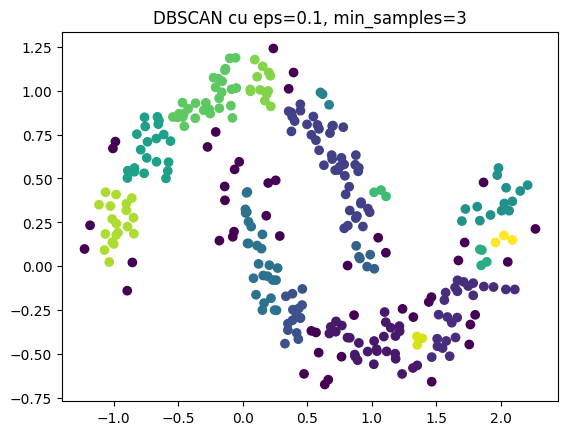

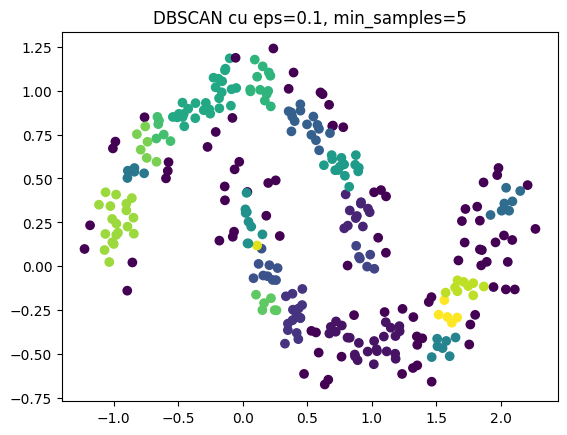

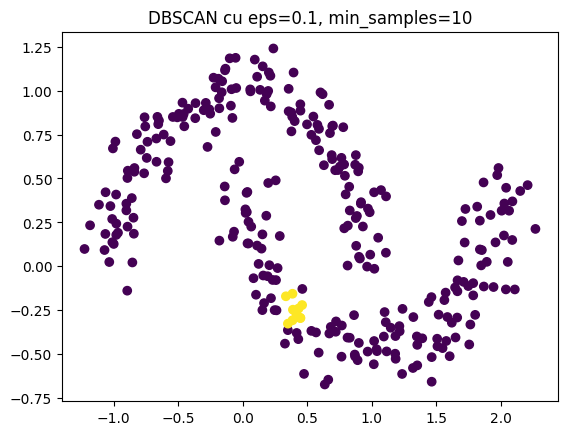

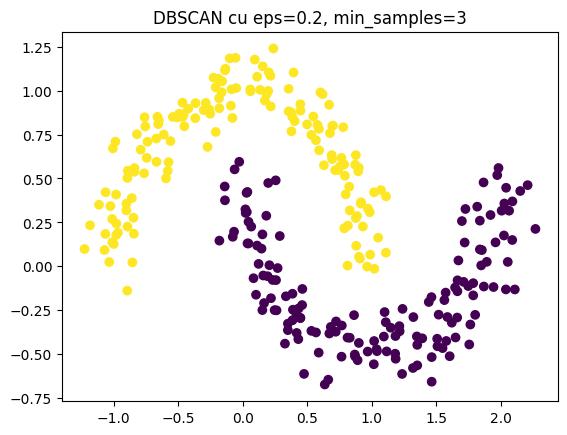

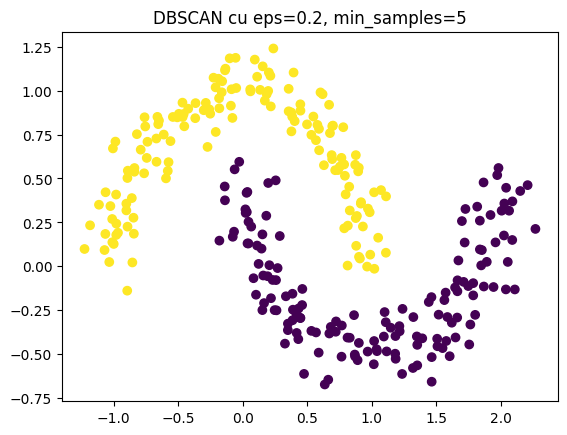

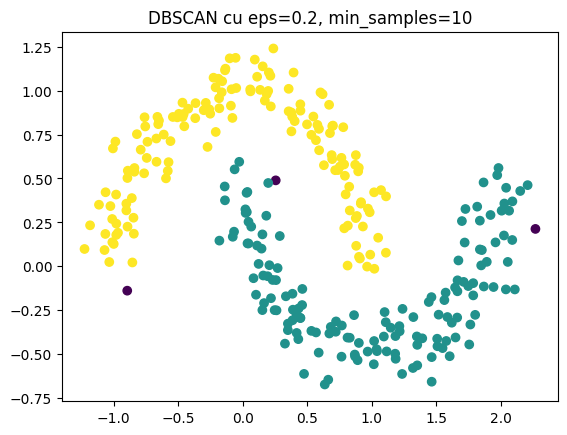

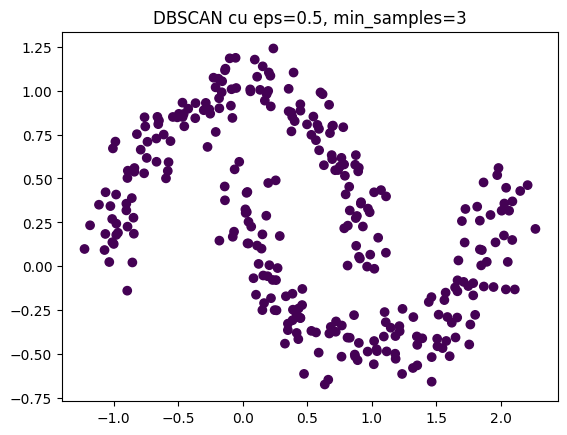

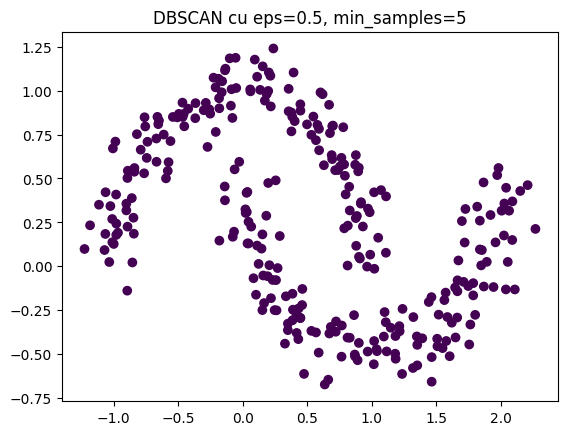

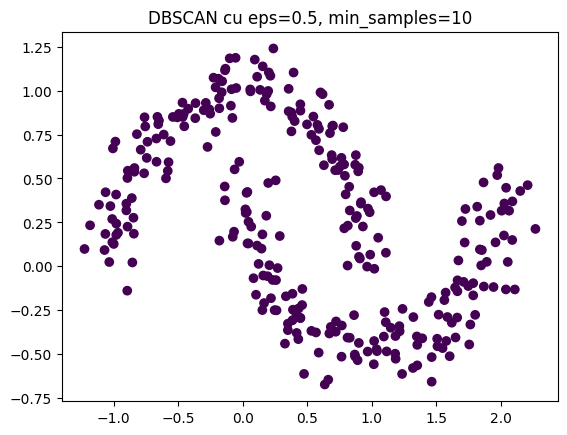

In [7]:
# Exemplu de experimentare cu parametri
for eps in [0.1, 0.2, 0.5]:
    for min_samples in [3, 5, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(X)
        plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels, cmap='viridis')
        plt.title(f'DBSCAN cu eps={eps}, min_samples={min_samples}')
        plt.show()

## 4. Concluzie

În acest tutorial, am învățat despre algoritmul DBSCAN, l-am implementat de la zero și l-am aplicat pe seturi de date de exemplu. Am explorat, de asemenea, exerciții pentru a consolida înțelegerea, inclusiv compararea cu Scikit-Learn și analiza parametrilor.

DBSCAN este un algoritm puternic pentru clustering, deoarece poate detecta clustere de forme arbitrare și puncte de zgomot. Cu toate acestea, alegerea parametrilor `eps` și `min_samples` este crucială pentru performanța sa.